In [106]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("iris") 

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


#### Phần 1: Thống kê mô tả và đặc trưng

In [107]:
# Task 1

display(df.head())

rows, collumns = df.shape
print(f"Số dòng: {rows}")
print(f"Số cột: {collumns}")


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Số dòng: 150
Số cột: 5


In [108]:
#Task 2
num_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

arr = {}

for col in num_cols:
    s = df[col]

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    arr[col] = {
        'mean': s.mean(),
        'median': s.median(),
        'mode': s.mode()[0],
        'variance:': s.var(),
        'std': s.std(),
        'min': s.min(),
        'max': s.max(),
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr
    }
res = pd.DataFrame(arr)
display(res.round(4))


,sepal_length,sepal_width,petal_length,petal_width
mean,5.8433,3.0573,3.7580,1.1993
median,5.8000,3.0000,4.3500,1.3000
mode,5.0000,3.0000,1.4000,0.2000
variance:,0.6857,0.1900,3.1163,0.5810
std,0.8281,0.4359,1.7653,0.7622
min,4.3000,2.0000,1.0000,0.1000
max,7.9000,4.4000,6.9000,2.5000
Q1,5.1000,2.8000,1.6000,0.3000
Q3,6.4000,3.3000,5.1000,1.8000
IQR,1.3000,0.5000,3.5000,1.5000


In [109]:
#Task 3
grouped_stats = df.groupby('species')[num_cols].agg(['mean', 'std'])
display(grouped_stats.round(3))

sepal_length        sepal_width        petal_length         \
                   mean    std        mean    std         mean    std   
species                                                                 
setosa            5.006  0.352       3.428  0.379        1.462  0.174   
versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
virginica         6.588  0.636       2.974  0.322        5.552  0.552   

           petal_width         
                  mean    std  
species                        
setosa           0.246  0.105  
versicolor       1.326  0.198  
virginica        2.026  0.275

## Nhận xét nhóm khác biệt rõ nhất:
- Loài **Setosa** có sự khác biệt rõ rệt nhất so với hai loài còn lại (Versicolor và Virginica). 
- Cụ thể, các đặc trưng cánh hoa của loài Setosa vô cùng nhỏ: chiều dài cánh hoa (`petal_length`) trung bình chỉ khoảng **1.46cm** (so với 4.26cm của Versicolor và 5.55cm của Virginica) và chiều rộng cánh hoa (`petal_width`) trung bình chỉ **0.24cm** (so với 1.33cm và 2.03cm).
- Ngược lại, loài Setosa có đài hoa ngắn nhưng chiều rộng đài hoa (`sepal_width`) lại lớn nhất và có độ lệch chuẩn nhỏ (dữ liệu rất tập trung).

#### Phần 2: Xác suất thống kê

##### Phần 1: Vẽ Histogram + KDE cho từng biến số

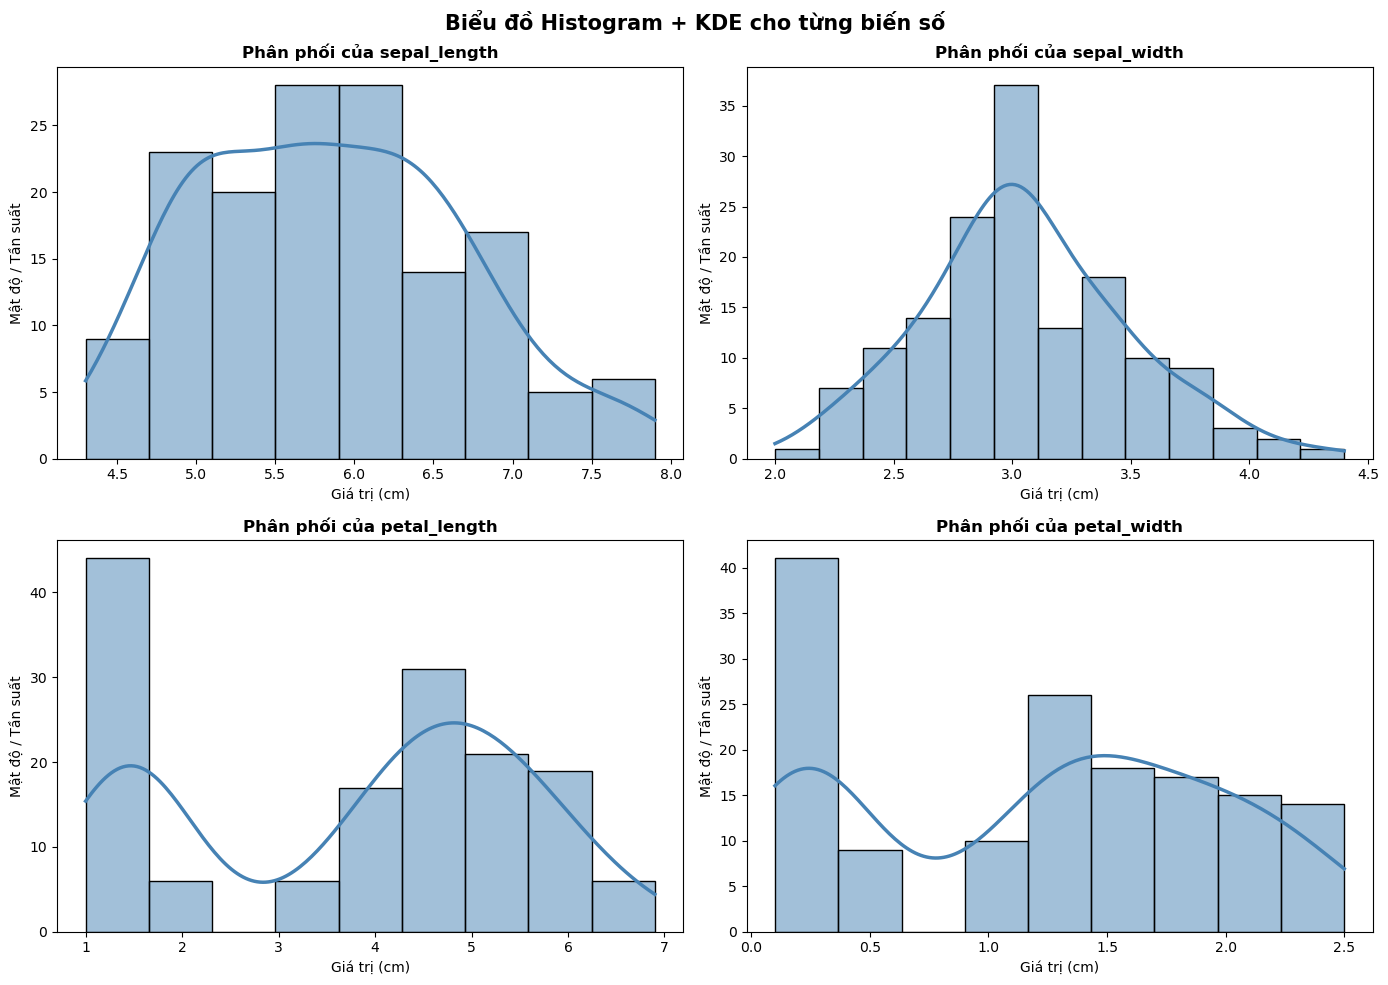

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue',
                    line_kws={'color':'red', 'linewidth':2.5})
    axes[i].set_title(f"Phân phối của {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Giá trị (cm)")
    axes[i].set_ylabel("Mật độ / Tần suất")

plt.suptitle("Biểu đồ Histogram + KDE cho từng biến số", fontsize=15,fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

- `sepal_length` & `sepal_width`: Phân phối tương đối đối xứng, có dạng hình chuông và khá gần với phân phối chuẩn . Trong đó `sepal_width` là biến giống phân phối chuẩn nhất.
- `petal_length` & `petal_width`: Phân phối không chuẩn và xuất hiện hai đỉnh rõ rệt. Điều này cho thấy dữ liệu của hai biến này bị chia làm 2 cụm rất rõ ràng, một nhóm hoa có cánh nhỏ tí hon và một nhóm hoa có cánh to hơn nhiều.

##### 2. Vẽ boxplot từng biến theo nhóm để so sánh

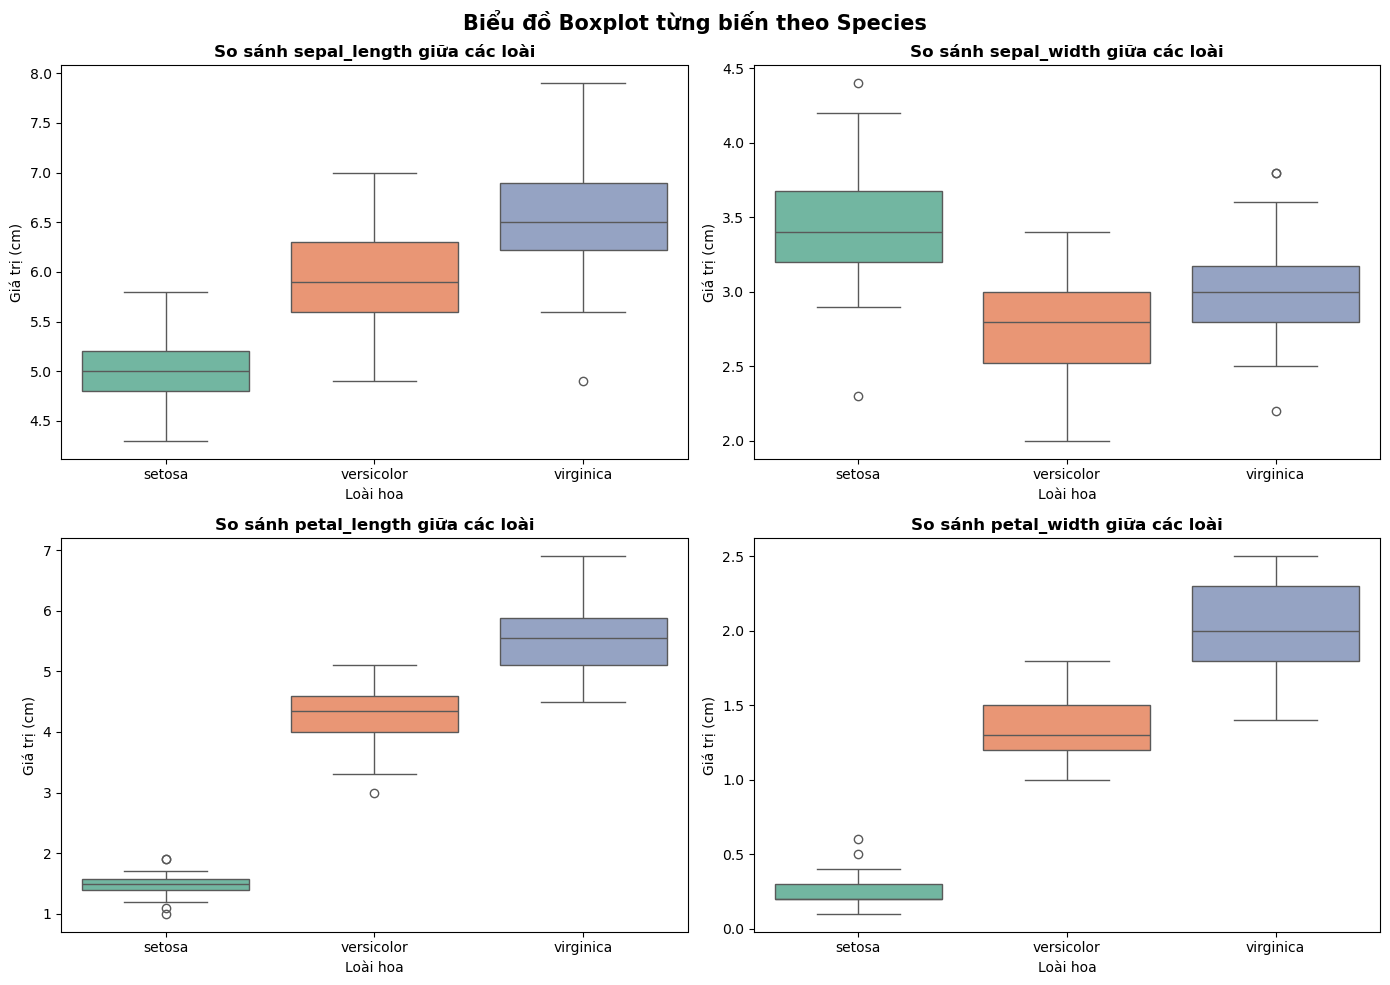

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='species', y=col, hue='species', data=df, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f"So sánh {col} giữa các loài", fontsize=12,
                        fontweight='bold')
    axes[i].set_xlabel("Loài hoa")
    axes[i].set_ylabel("Giá trị (cm)")

plt.suptitle("Biểu đồ Boxplot từng biến theo Species",
            fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


- `Setosa` luôn có các chỉ số cánh hoa (`petal_length`, `petal_width`) cực kỳ nhỏ và hoàn toàn tách biệt khỏi hai loài kia.
- `Virginica` có kích thước các bộ phận nói chung lớn nhất.
- `Versicolor` nằm ở giữa và có một chút chồng lấn kích thước đài hoa với Virginica. Có một vài điểm ngoại lai xuất hiện ngoài râu (whisker) ở một số loài.

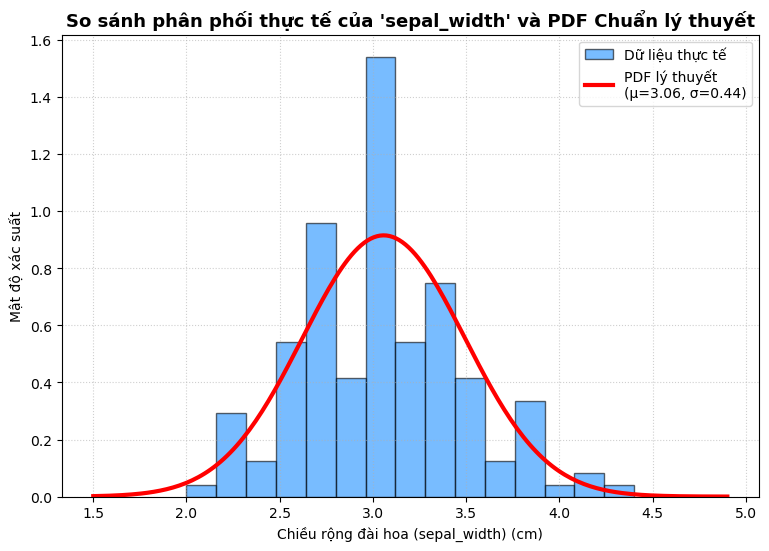

In [112]:
from scipy.stats import norm

import numpy as np

col = 'sepal_width'
mu = df[col].mean()
sigma = df[col].std()

simulated_data = np.random.normal(mu, sigma, 1000)

plt.figure(figsize=(9, 6))
plt.hist(df[col], bins=15, density=True, alpha=0.6, color='dodgerblue', edgecolor='black', label='Dữ liệu thực tế')

x_axis = np.linspace(df[col].min() - 0.5, df[col].max() + 0.5, 200)
plt.plot(x_axis, norm.pdf(x_axis, mu, sigma), color='red', linewidth=3, label=f'PDF lý thuyết\n(μ={mu:.2f}, σ={sigma:.2f})')
plt.title(f"So sánh phân phối thực tế của '{col}' và PDF Chuẩn lý thuyết", fontsize=13, fontweight='bold')
plt.xlabel("Chiều rộng đài hoa (sepal_width) (cm)")
plt.ylabel("Mật độ xác suất")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


- Đường cong phân phối chuẩn lý thuyết khớp rất tốt với biểu đồ cột tần suất thực tế của biến `sepal_width`.
- Điều này chứng tỏ biến `sepal_width` tuân theo quy luật phân phối chuẩn rất tốt trong tự nhiên, thích hợp cho các mô hình giả định phân phối chuẩn.

#### Phần 3: Phân tích đa biến và Tương quan

In [113]:
# Task 1
cov_matrix = df[num_cols].cov()
print("Ma trận hiệp phương sai:")
display(cov_matrix.round(4))


corr_matrix = df[num_cols].corr()
print("Ma trận tương quan:")
display(corr_matrix.round(4))


Ma trận hiệp phương sai:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.6857,-0.0424,1.2743,0.5163
sepal_width,-0.0424,0.1900,-0.3297,-0.1216
petal_length,1.2743,-0.3297,3.1163,1.2956
petal_width,0.5163,-0.1216,1.2956,0.5810


Ma trận tương quan:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.0000,-0.1176,0.8718,0.8179
sepal_width,-0.1176,1.0000,-0.4284,-0.3661
petal_length,0.8718,-0.4284,1.0000,0.9629
petal_width,0.8179,-0.3661,0.9629,1.0000


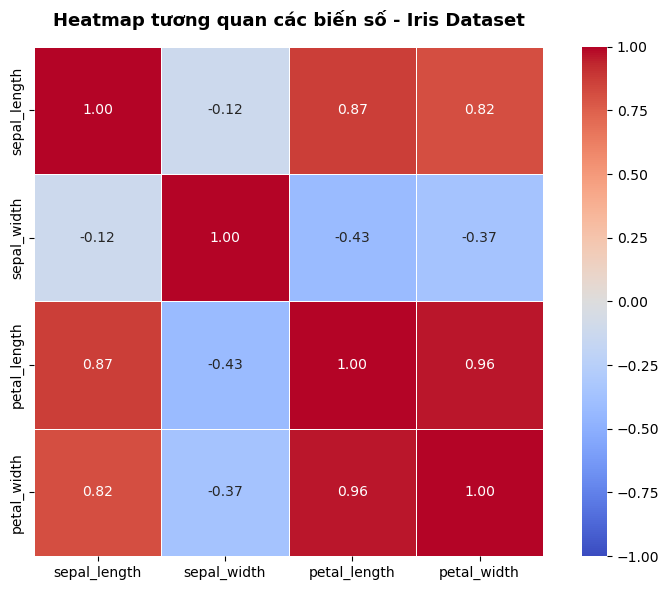

In [114]:
#Task 2
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt=".2f",          
    cmap='coolwarm',    
    vmin=-1, vmax=1,   
    square=True,        
    linewidths=0.5     
)
plt.title("Heatmap tương quan các biến số - Iris Dataset", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### Nhận xét:
- **Cặp tương quan mạnh nhất:** `petal_length` và `petal_width` có hệ số tương quan ~**0.96** (gần bằng 1), đây là tương quan dương rất mạnh, nghĩa là hoa càng dài cánh thì cánh càng rộng.
- **Tương quan dương mạnh thứ 2:** `sepal_length` với `petal_length` (~0.87) và `sepal_length` với `petal_width` (~0.82).
- **Tương quan âm:** `sepal_width` có tương quan âm yếu với các biến còn lại (~-0.11 đến -0.37), nghĩa là đài hoa rộng thì các kích thước cánh hoa có xu hướng hơi nhỏ hơn.
- **Dấu hiệu đa cộng tuyến:** `petal_length` và `petal_width` có tương quan 0.96 — nếu dùng trong mô hình hồi quy tuyến tính, hai biến này sẽ gây ra hiện tượng đa cộng tuyến, cần loại bỏ một trong hai hoặc dùng PCA để xử lý.

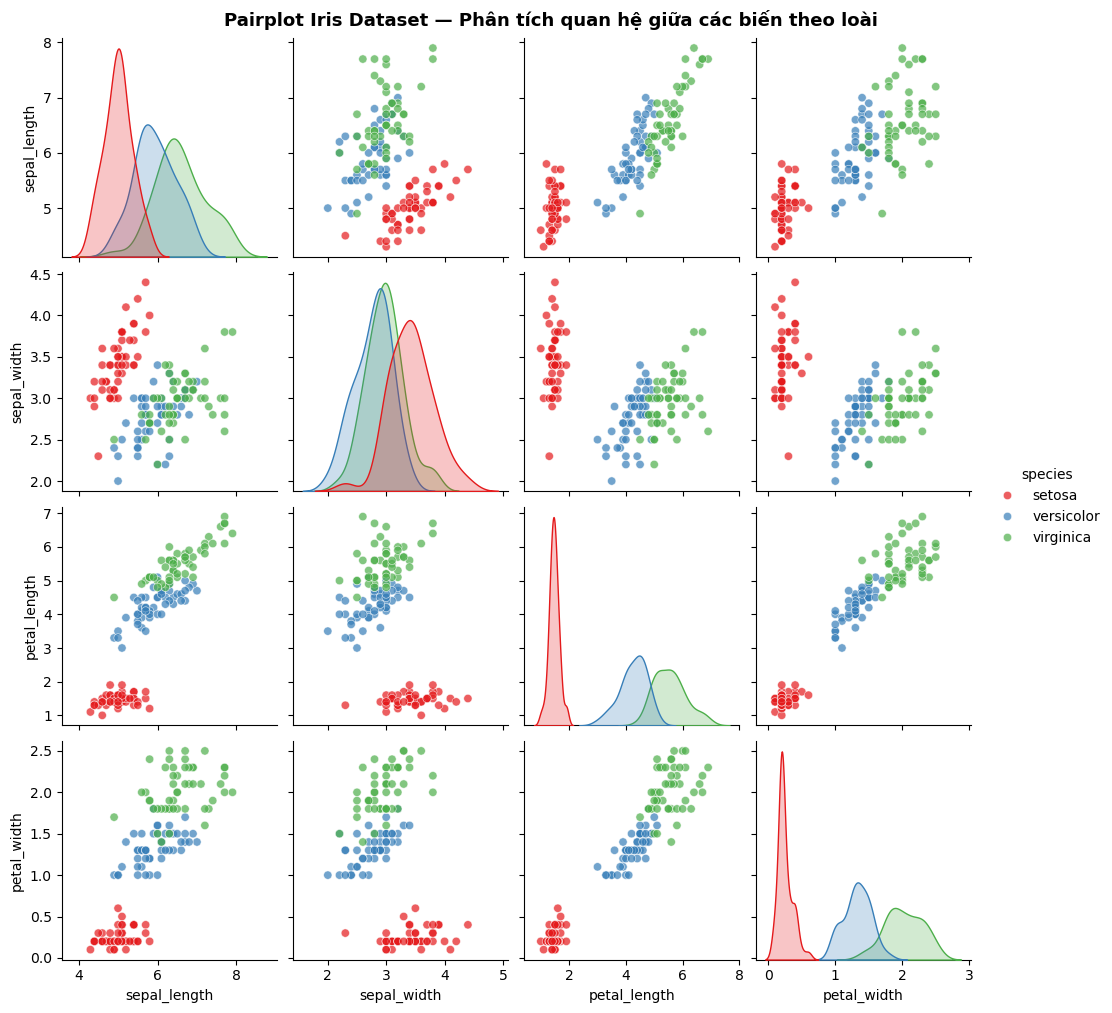

In [115]:
#Task 3
sns.pairplot(
    df, 
    hue='species',              
    palette='Set1',             
    plot_kws={'alpha': 0.7},    
    diag_kind='kde'         
)
plt.suptitle("Pairplot Iris Dataset — Phân tích quan hệ giữa các biến theo loài",
             y=1.01, fontsize=13, fontweight='bold')
plt.show()

#### Nhận xét Pairplot:
- **Setosa (đỏ)** hoàn toàn tách biệt với 2 loài còn lại ở tất cả các biểu đồ liên quan đến `petal_length` và `petal_width`.
- **Versicolor (xanh lá) và Virginica (xanh dương)** có sự chồng lấn nhau ở một số biểu đồ, đặc biệt là khi nhìn theo `sepal_length` và `sepal_width`.
- Các biểu đồ scatter của cặp `petal_length` vs `petal_width` cho thấy mối quan hệ tuyến tính rõ rệt nhất và sự phân tách tốt nhất giữa 3 loài.

#### Phần 4: Xác suất và Bayes

In [116]:
# Task 1
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05
P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos
print (round(P_B_given_pos, 4))

P_B_given_pos = (P_pos_givenB * P_B) / P_pos
print(f"Xác suất dương tính tổng thể P(+) = {P_pos:.4f}")
print(f"Xác suất thực sự mắc bệnh khi xét nghiệm dương tính:")
print(f"P(B | +) = {P_B_given_pos:.4f} = {P_B_given_pos*100:.2f}%")

0.1667
Xác suất dương tính tổng thể P(+) = 0.0594
Xác suất thực sự mắc bệnh khi xét nghiệm dương tính:
P(B | +) = 0.1667 = 16.67%


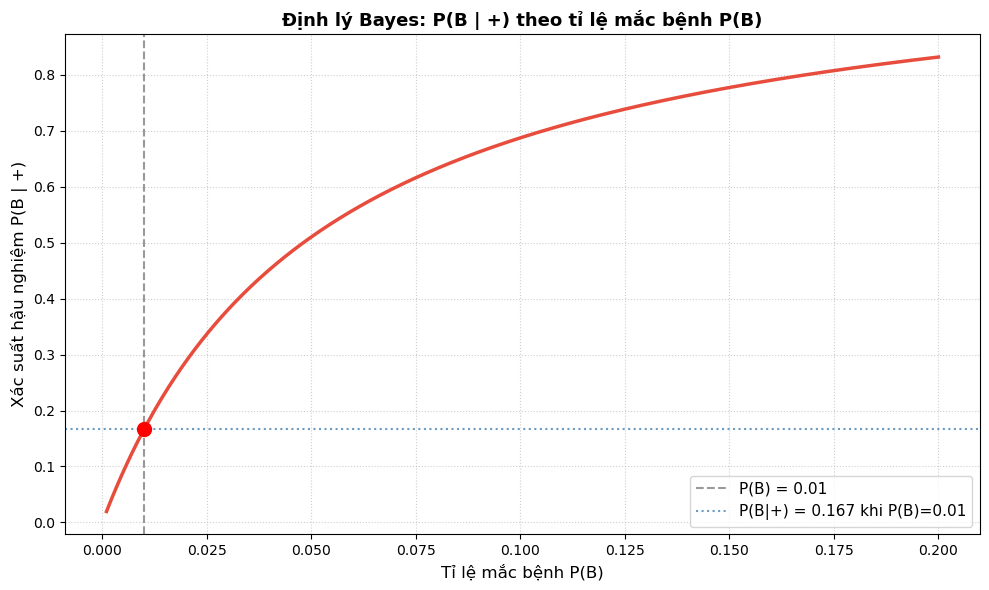

In [117]:
# Task 2

p_b_values = np.linspace(0.001, 0.2, 500)

p_pos_total    = P_pos_givenB * p_b_values + P_pos_givnNB * (1 - p_b_values)
p_b_given_pos  = (P_pos_givenB * p_b_values) / p_pos_total

plt.figure(figsize=(10, 6))
plt.plot(p_b_values, p_b_given_pos, color='#e74c3c', linewidth=2.5)

plt.axvline(x=0.01, color='gray', linestyle='--', alpha=0.8, label='P(B) = 0.01')
plt.axhline(y=P_B_given_pos, color='steelblue', linestyle=':', alpha=0.8,
            label=f'P(B|+) = {P_B_given_pos:.3f} khi P(B)=0.01')
plt.scatter([0.01], [P_B_given_pos], color='red', s=100, zorder=5)

plt.xlabel("Tỉ lệ mắc bệnh P(B)", fontsize=12)
plt.ylabel("Xác suất hậu nghiệm P(B | +)", fontsize=12)
plt.title("Định lý Bayes: P(B | +) theo tỉ lệ mắc bệnh P(B)", fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Giải thích hiện tượng "phản trực giác":
- Khi P(B) = 0.01 (bệnh hiếm, chỉ 1% dân số mắc), dù xét nghiệm có độ nhạy cao đến 99%, xác suất thực sự mắc bệnh khi có kết quả dương tính chỉ khoảng **~16.6%**.
- **Lý do:** Vì bệnh rất hiếm, trong 10,000 người thì chỉ có 100 người thực sự bệnh. Nhưng trong 9,900 người lành, sẽ có khoảng 5% × 9,900 = 495 người bị dương tính giả. Do đó, trong tổng số ~595 người dương tính, chỉ 100 người thực sự bệnh (~16.8%).
- **Bài học:** Khi bệnh càng hiếm, kết quả dương tính của xét nghiệm càng kém tin cậy. Đây là lý do tại sao các chương trình xét nghiệm tầm soát đại trà thường cần xét nghiệm xác nhận lần 2 trước khi kết luận.

In [118]:
#Task 3: 
spam_words = {'free', 'win', 'prize', 'click', 'offer', 'money', 'limited', 'congratulations'}
ham_words  = {'meeting', 'project', 'report', 'schedule', 'team', 'update', 'deadline', 'agenda'}
P_spam = 0.3  # Giả sử 30% email đến là spam
def naive_bayes_spam(email_text):
    words = set(email_text.lower().split())
    
    log_p_spam = np.log(P_spam)
    log_p_ham  = np.log(1 - P_spam)
    
    for w in words:
        if w in spam_words:
            log_p_spam += np.log(0.8)  
            log_p_ham  += np.log(0.1)  
        elif w in ham_words:
            log_p_spam += np.log(0.1) 
            log_p_ham  += np.log(0.8) 
    p_spam = np.exp(log_p_spam)
    p_ham  = np.exp(log_p_ham)
    p_spam_norm = p_spam / (p_spam + p_ham)
    return p_spam_norm

test_emails = [
    "Click here to win free money and prize offer",
    "Team meeting report and project update deadline",
    "Congratulations you win a limited free offer click now"
]
print("=" * 70)
for email in test_emails:
    score = naive_bayes_spam(email)
    nhan  = "SPAM" if score > 0.5 else "Bình thường"
    print(f"Email : '{email}'")
    print(f"P(spam): {score:.4f}  →  Phân loại: {nhan}")
    print("-" * 70)

Email : 'Click here to win free money and prize offer'
P(spam): 1.0000  →  Phân loại: SPAM
----------------------------------------------------------------------
Email : 'Team meeting report and project update deadline'
P(spam): 0.0000  →  Phân loại: Bình thường
----------------------------------------------------------------------
Email : 'Congratulations you win a limited free offer click now'
P(spam): 1.0000  →  Phân loại: SPAM
----------------------------------------------------------------------
